<a href="https://colab.research.google.com/github/ihanprasetyo/mimic-los-prediction-tutorial/blob/main/mimic_los_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Hospital and ICU Length of Stay using MIMIC-III
AI in Healthcare Tutorial

This tutorial demonstrates how machine learning can predict hospital
resource utilization using the MIMIC-III clinical dataset.

We will predict:

1. Hospital length of stay
2. ICU length of stay

## 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Mount Google Drive and Define Data Path

In [3]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/mimic_data/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Load MIMIC Tables

In [5]:
patients = pd.read_csv(DATA_PATH + "PATIENTS.csv")
admissions = pd.read_csv(DATA_PATH + "ADMISSIONS.csv")
icustays = pd.read_csv(DATA_PATH + "ICUSTAYS.csv")

print("Patients:", patients.shape)
print("Admissions:", admissions.shape)
print("ICU stays:", icustays.shape)

Patients: (46520, 8)
Admissions: (58976, 19)
ICU stays: (61532, 12)


## 4. Merge Tables

In [6]:
# Merge PATIENTS and ADMISSIONS
df = pd.merge(admissions, patients, on="SUBJECT_ID", how="inner")

# Merge with ICU stays
df = pd.merge(df, icustays, on=["SUBJECT_ID", "HADM_ID"], how="inner")

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (61532, 36)


,ROW_ID_x,SUBJECT_ID,HADM_ID,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,...,ROW_ID,ICUSTAY_ID,DBSOURCE,FIRST_CAREUNIT,LAST_CAREUNIT,FIRST_WARDID,LAST_WARDID,INTIME,OUTTIME,LOS
0,21,22,165315,2196-04-09 12:26:00,2196-04-10 15:54:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,DISC-TRAN CANCER/CHLDRN H,Private,...,22,204798,carevue,MICU,MICU,52,52,2196-04-09 12:27:00,2196-04-10 15:54:00,1.1438
1,22,23,152223,2153-09-03 07:15:00,2153-09-08 19:10:00,NaN,ELECTIVE,PHYS REFERRAL/NORMAL DELI,HOME HEALTH CARE,Medicare,...,23,227807,carevue,CSRU,CSRU,14,14,2153-09-03 09:38:55,2153-09-04 15:59:11,1.2641
2,23,23,124321,2157-10-18 19:34:00,2157-10-25 14:00:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME HEALTH CARE,Medicare,...,24,234044,metavision,SICU,SICU,57,57,2157-10-21 11:40:38,2157-10-22 16:08:48,1.1862
3,24,24,161859,2139-06-06 16:14:00,2139-06-09 12:48:00,NaN,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,HOME,Private,...,25,262236,carevue,CCU,CCU,7,7,2139-06-06 16:15:36,2139-06-07 04:33:25,0.5124
4,25,25,129635,2160-11-02 02:06:00,2160-11-05 14:55:00,NaN,EMERGENCY,EMERGENCY ROOM ADMIT,HOME,Private,...,26,203487,carevue,CCU,CCU,7,7,2160-11-02 03:16:23,2160-11-05 16:23:27,3.5466


## 5. Convert Date Columns

In [7]:
date_cols = [
    "ADMITTIME",
    "DISCHTIME",
    "DOB",
    "INTIME",
    "OUTTIME"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df[date_cols].head()

,ADMITTIME,DISCHTIME,DOB,INTIME,OUTTIME
0,2196-04-09 12:26:00,2196-04-10 15:54:00,2131-05-07,2196-04-09 12:27:00,2196-04-10 15:54:00
1,2153-09-03 07:15:00,2153-09-08 19:10:00,2082-07-17,2153-09-03 09:38:55,2153-09-04 15:59:11
2,2157-10-18 19:34:00,2157-10-25 14:00:00,2082-07-17,2157-10-21 11:40:38,2157-10-22 16:08:48
3,2139-06-06 16:14:00,2139-06-09 12:48:00,2100-05-31,2139-06-06 16:15:36,2139-06-07 04:33:25
4,2160-11-02 02:06:00,2160-11-05 14:55:00,2101-11-21,2160-11-02 03:16:23,2160-11-05 16:23:27


## 6. Create Length of Stay Variables

In [8]:
# Hospital Length of Stay (days)
df["hospital_los_days"] = (df["DISCHTIME"] - df["ADMITTIME"]).dt.total_seconds() / (24 * 3600)

# ICU Length of Stay (days)
df["icu_los_days"] = (df["OUTTIME"] - df["INTIME"]).dt.total_seconds() / (24 * 3600)

df[["hospital_los_days", "icu_los_days"]].describe()

,hospital_los_days,icu_los_days
count,61532.000000,61522.000000
mean,11.311092,4.917971
std,14.278520,9.638784
min,-0.945139,0.000139
25%,3.907639,1.108070
50%,6.945833,2.092234
75%,13.051562,4.483157
max,294.660417,173.072512


## 7. Compute Patient's Age

In [11]:
df["age"] = df["ADMITTIME"].dt.year - df["DOB"].dt.year

# MIMIC caps age > 89 for privacy
df.loc[df["age"] > 90, "age"] = 90
df.loc[df["age"] < 0, "age"] = np.nan

df["age"].describe()

,age
count,61532.000000
mean,55.573198
std,26.926056
min,0.000000
25%,44.000000
50%,62.000000
75%,76.000000
max,90.000000


## 8. Raw Data Visualization

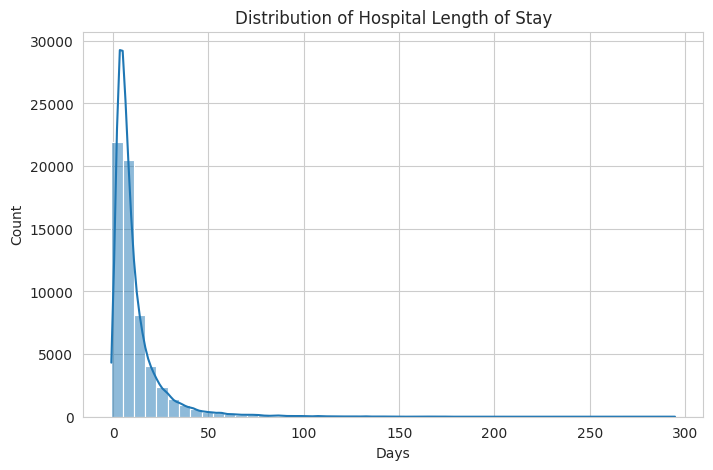

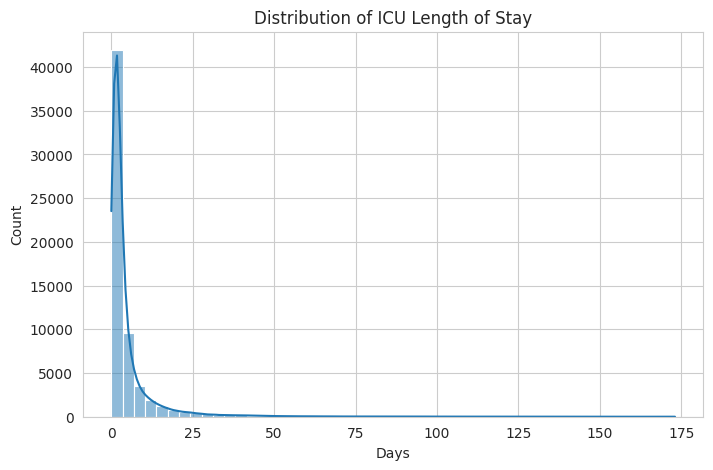

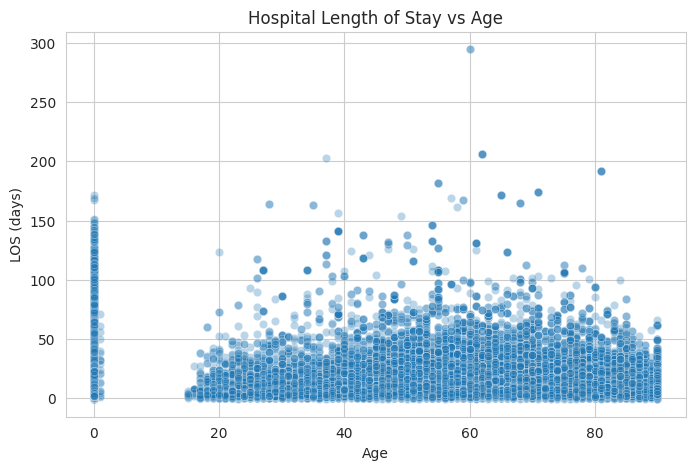

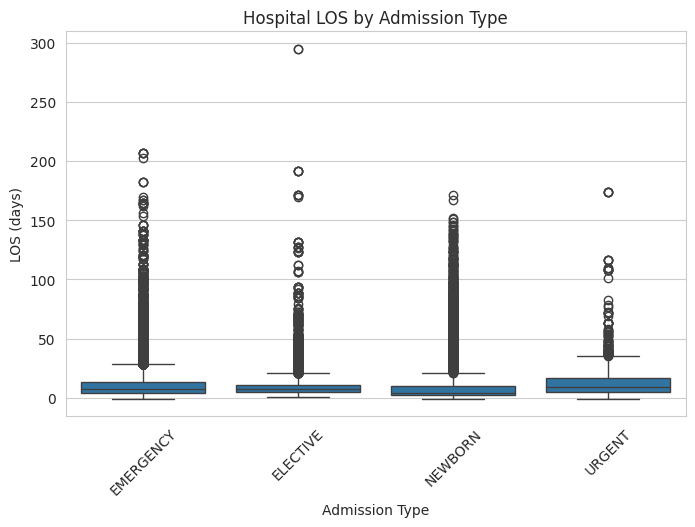

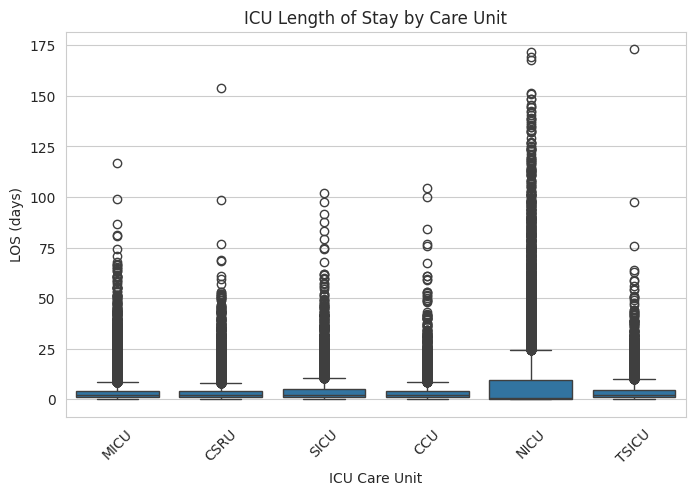

In [12]:
sns.set_style("whitegrid")

# --------------------------------
# Hospital Length of Stay Distribution
# --------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df["hospital_los_days"], bins=50, kde=True)

plt.title("Distribution of Hospital Length of Stay")
plt.xlabel("Days")
plt.ylabel("Count")

plt.show()


# --------------------------------
# ICU Length of Stay Distribution
# --------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df["icu_los_days"].dropna(), bins=50, kde=True)

plt.title("Distribution of ICU Length of Stay")
plt.xlabel("Days")
plt.ylabel("Count")

plt.show()


# --------------------------------
# Hospital LOS vs Age
# --------------------------------

plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="hospital_los_days", data=df, alpha=0.3)

plt.title("Hospital Length of Stay vs Age")
plt.xlabel("Age")
plt.ylabel("LOS (days)")

plt.show()


# --------------------------------
# Hospital LOS by Admission Type
# --------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(x="ADMISSION_TYPE", y="hospital_los_days", data=df)

plt.title("Hospital LOS by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("LOS (days)")

plt.xticks(rotation=45)

plt.show()


# --------------------------------
# ICU LOS by Care Unit
# --------------------------------

plt.figure(figsize=(8,5))
sns.boxplot(x="FIRST_CAREUNIT", y="icu_los_days", data=df)

plt.title("ICU Length of Stay by Care Unit")
plt.xlabel("ICU Care Unit")
plt.ylabel("LOS (days)")

plt.xticks(rotation=45)

plt.show()

## 9. Feature Correlation Heatmap

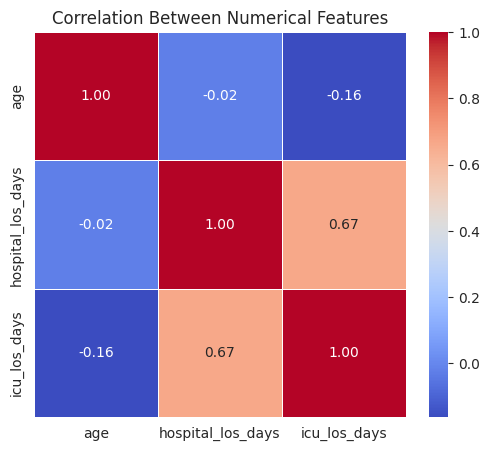

In [13]:
# Select numerical columns
numeric_df = df[[
    "age",
    "hospital_los_days",
    "icu_los_days"
]]

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Between Numerical Features")

plt.show()

## 10. Data Sanity Checks

In [15]:
# Dataset size
print("Dataset shape:", df.shape)

# Check missing values
print("\nMissing values per column:")
print(df.isna().sum())

# Summary statistics for numerical features
print("\nSummary statistics:")
print(df[["age", "hospital_los_days", "icu_los_days"]].describe())

# Check LOS ranges
print("\nMax hospital LOS:", df["hospital_los_days"].max())
print("Max ICU LOS:", df["icu_los_days"].max())

# Check age range
print("\nMin age:", df["age"].min())
print("Max age:", df["age"].max())

# Count admission types
print("\nAdmission type counts:")
print(df["ADMISSION_TYPE"].value_counts())

# Count ICU units
print("\nICU care unit counts:")
print(df["FIRST_CAREUNIT"].value_counts())

Dataset shape: (61532, 39)

Missing values per column:
ROW_ID_x                    0
SUBJECT_ID                  0
HADM_ID                     0
ADMITTIME                   0
DISCHTIME                   0
DEATHTIME               54923
ADMISSION_TYPE              0
ADMISSION_LOCATION          0
DISCHARGE_LOCATION          0
INSURANCE                   0
LANGUAGE                26154
RELIGION                  480
MARITAL_STATUS          10240
ETHNICITY                   0
EDREGTIME               28760
EDOUTTIME               28760
DIAGNOSIS                   1
HOSPITAL_EXPIRE_FLAG        0
HAS_CHARTEVENTS_DATA        0
ROW_ID_y                    0
GENDER                      0
DOB                         0
DOD                     37341
DOD_HOSP                45318
DOD_SSN                 41079
EXPIRE_FLAG                 0
ROW_ID                      0
ICUSTAY_ID                  0
DBSOURCE                    0
FIRST_CAREUNIT              0
LAST_CAREUNIT               0
FIRST_WARDID   

In [ ]:
## 11. Data Cleaning

In [17]:
# Remove rows with negative hospital LOS
df = df[df["hospital_los_days"] >= 0]

# Remove rows with missing ICU LOS
df = df.dropna(subset=["icu_los_days"])

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (61438, 39)


## 12. Data Preparation for Machine Learning

In [18]:
# Select predictive features
features = [
    "age",
    "GENDER",
    "ADMISSION_TYPE",
    "ADMISSION_LOCATION",
    "INSURANCE",
    "MARITAL_STATUS",
    "ETHNICITY",
    "FIRST_CAREUNIT"
]

X = df[features]

# Define prediction targets
y_hospital = df["hospital_los_days"]
y_icu = df["icu_los_days"]

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Check dataset
print("Feature matrix shape:", X.shape)
print("Hospital LOS target:", y_hospital.shape)
print("ICU LOS target:", y_icu.shape)

Feature matrix shape: (61438, 68)
Hospital LOS target: (61438,)
ICU LOS target: (61438,)


## 13. Split Data into Training and Testing Sets

In [19]:
# Hospital LOS split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X, y_hospital, test_size=0.2, random_state=42
)

# ICU LOS split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X, y_icu, test_size=0.2, random_state=42
)

print("Hospital training set:", X_train_h.shape)
print("Hospital test set:", X_test_h.shape)

print("ICU training set:", X_train_i.shape)
print("ICU test set:", X_test_i.shape)

Hospital training set: (49150, 68)
Hospital test set: (12288, 68)
ICU training set: (49150, 68)
ICU test set: (12288, 68)


## 14. Random Forest Model Training

In [20]:
# Train model for hospital LOS
rf_hospital = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_hospital.fit(X_train_h, y_train_h)

# Train model for ICU LOS
rf_icu = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_icu.fit(X_train_i, y_train_i)

print("Both Random Forest models have been trained.")

Both Random Forest models have been trained.


## 15. Model Evaluation

In [23]:
pred_h = rf_hospital.predict(X_test_h)
pred_i = rf_icu.predict(X_test_i)

print("Hospital LOS Performance")
print("MAE:", mean_absolute_error(y_test_h, pred_h))
print("RMSE:", np.sqrt(mean_squared_error(y_test_h, pred_h)))
print("R²:", r2_score(y_test_h, pred_h))

print()

print("ICU LOS Performance")
print("MAE:", mean_absolute_error(y_test_i, pred_i))
print("RMSE:", np.sqrt(mean_squared_error(y_test_i, pred_i)))
print("R²:", r2_score(y_test_i, pred_i))

Hospital LOS Performance
MAE: 8.259697320442706
RMSE: 13.689989486567669
R²: 0.09542473138437924

ICU LOS Performance
MAE: 4.7332855311187005
RMSE: 9.585986069092709
R²: 0.03992846981184328
